In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
columns = [
    "transaction_id", "transaction_amount", "login_attempts", "device_risk_score", "transfer_frequency", "anomaly_score", "account_age_days", "transaction_time_hour", "failed_transactions_last_30d", "avg_monthly_balance", "daily_transaction_count", "geo_distance_km", "session_duration_minutes", "transaction_velocity_score", "payment_channel", "authentication_type", "card_present_flag", "international_transaction_flag", "suspicious_ip_flag", "fraud_flag"
]

In [4]:
df = pd.read_csv("banking_transactions.csv")
df.head()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [5]:
X = df.drop(columns=['transaction_id', 'fraud_flag'])
y = df['fraud_flag'].astype(int)

In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Rozmiar danych treningowych: {X_train.shape}")
print(f"Rozmiar danych testowych: {X_test.shape}")

Rozmiar danych treningowych: (8000, 22)
Rozmiar danych testowych: (2000, 22)


In [8]:
#Trenowanie drzewa decyzyjengo
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

f1_dt = f1_score(y_test, y_pred_dt)
acc_dt = accuracy_score(y_test, y_pred_dt)

print('f1-score:', f1_dt)
print('accuracy:', acc_dt)

f1-score: 0.672
accuracy: 0.918


In [9]:
# Trenowanie XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

f1_xgb = f1_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("f1_score:", f1_xgb)
print('accuracy:', acc_xgb)

f1_score: 0.78099173553719
accuracy: 0.947


In [10]:
print('Porównanie wyników')
print(f"Drzewo Decyzyjne: Accuracy: {acc_dt:.3f}, F1-Score: {f1_dt:.3f}")
print(f"XGBoost: Accuracy: {acc_xgb:.3f}, F1-Score: {f1_xgb:.3f}")

Porównanie wyników
Drzewo Decyzyjne: Accuracy: 0.918, F1-Score: 0.672
XGBoost: Accuracy: 0.947, F1-Score: 0.781


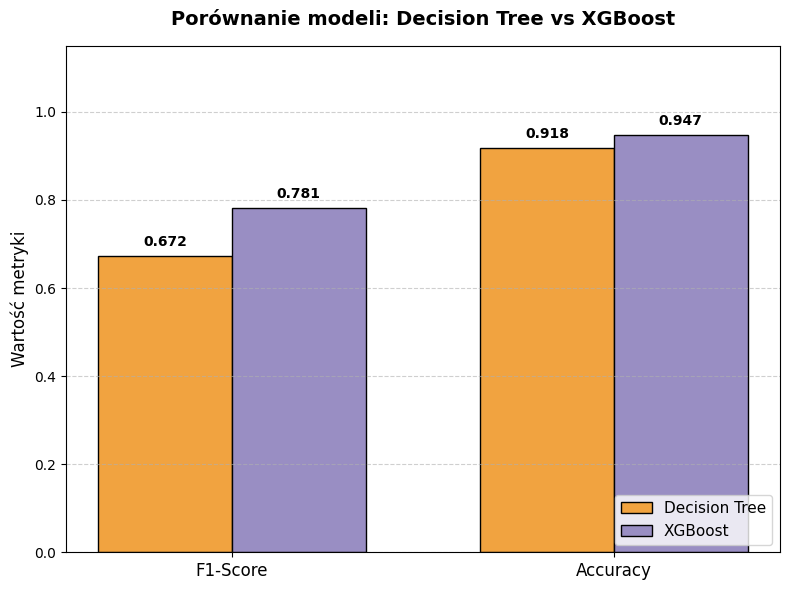

In [ ]:
labels = ['F1-Score', 'Accuracy']
dt_scores = [f1_dt, acc_dt]
xgb_scores = [f1_xgb, acc_xgb]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - width/2, dt_scores, width, label='Decision Tree', color='#F1A340', edgecolor='black')
rects2 = ax.bar(x + width/2, xgb_scores, width, label='XGBoost', color='#998EC3', edgecolor='black')

ax.set_ylabel('Wartość metryki', fontsize=12)
ax.set_title('Porównanie modeli: Decision Tree vs XGBoost', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

In [11]:
# Lepszy wynik osiągnął model XGBoost, który uzyskał wyższą wartość zarówno dla accuracy, jak i f1-score w porównaniu do drzewa decyzyjnego.

In [12]:
#Strojenie hiperparametrow dla XGBoost
param_grid = {
    'max_depth': [3, 10],
    'learning_rate': [0.01, 0.2],
    'n_estimators': [100, 500]
}
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=1
)

In [13]:
grid_search.fit(X_train, y_train) #szukanie najlepszych parametrow

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.2], 'max_depth': [3, 10], 'n_estimators': [100, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [14]:
print("Najlepsze dobrane parametry:", grid_search.best_params_)

Najlepsze dobrane parametry: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}


In [15]:
final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test)

In [16]:
print("Pełen raport klasyfikacji")
print(classification_report(y_test, y_pred_final))

Pełen raport klasyfikacji
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1751
           1       0.83      0.78      0.81       249

    accuracy                           0.95      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.95      0.95      0.95      2000

